# Precision neurolinguistics reveals latent speech signatures of a negative affect biotype and its modulation by MDMA

#### Elizabeth H. Beam, Xue Zhang, Rachel Hilton, Peter J. van Roessel, Carolyn I. Rodriguez, & Leanne M. Williams

<b>Purpose:</b> This notebook provides a walkthrough of all main-text and supplementary analyses reported in the manuscript. 

<b>Background:</b> Our study introduces a precision neurolinguistics framework in which brain circuit stratification guides the discovery of latent speech signatures using generative AI (GPT-5). Working with naturalistic speech recorded from participants during placebo and MDMA sessions, we demonstrate that AI-derived speech signatures can classify subgroups of a negative affective biotype defined by amygdala reactivity to nonconscious social threat at baseline. The biotype subgroups were previously shown by [Zhang <i>et al.</i>](https://jamanetwork.com/journals/jamanetworkopen/fullarticle/2833328) to respond differently to MDMA, with those showing high amygdala reactivity (NTN<sub>A+</sub>) at baseline shifting toward normalization of circuit function. The AI-derived speech signatures track this state-dependent modulation of the high amygdala reactivity (NTN<sub>A+</sub>) subgroup under MDMA. Further, in follow-up analyses, the speech signatures contextualize otherwise paradoxical findings of hyper-positive verbal expression during placebo as a defensive stance that reverses with MDMA.

<b>Data Availability:</b> Participant speech data are not included in this repository. Transcripts are available upon request from the corresponding author following approval of a proposal for a specified purpose. For an application of the neurolinguistics pipeline to synethetic transcript data, please see the "example" notebook.

In [1]:
import utils
import transcribe
import featurize
import visualize
from style import style

import os
import scipy
import numpy as np
import pandas as pd

In [2]:
pd.set_option("display.width", 1000)

In [3]:
biotypes = ["low", "high"]
conditions = ["placebo", "mdma_high"]
splits = ["train", "valid", "test"]

n_blocks = 5
min_dur = 10
max_dur = 30
min_n_vars = 1
max_n_vars = 10
max_n_iter = 3

CI_width = 0.95
bootstrap_n_iter = 10000
permutation_n_iter = 10000

seed = 9

data_path = "manuscript/data"
table_path = "manuscript/tables"
model_path = "manuscript/features/send/models"
feature_path = "manuscript/features"
figure_path = "manuscript/figures"

## 0. Demographic differences

###### Table 1

In [4]:
demo_df = pd.read_csv(f"{data_path}/demographics.csv", 
                      index_col=None)
demo_df = demo_df[~(demo_df["Placebo"].isna()) | ~(demo_df["MDMA_High"].isna())]
demo_df.index = range(len(demo_df))

placebo_df = demo_df[~demo_df["Placebo"].isna()]
mdma_df = demo_df[~demo_df["MDMA_High"].isna()]
demo_dfs = {"combined": demo_df, "placebo": placebo_df, "mdma": mdma_df}

demo_stat_path = f"{table_path}/demographics"
demo_stat_df = utils.compute_demo_differences(demo_dfs, demo_stat_path, 
                                              conditions=conditions, verbose=True)

COMBINED
  condition             var  n_low  med_low  q1_low  q3_low  n_high  med_high  q1_high  q3_high  stat         p sig
0  combined             Age      5     35.0    35.0    36.0       5      42.0     32.0     46.0  11.0  0.834035    
0  combined          Gender      1      NaN     NaN     NaN       1       NaN      NaN      NaN   0.0  1.000000    
0  combined       Education      1      NaN     NaN     NaN       1       NaN      NaN      NaN   0.0  1.000000    
0  combined  ehi_handedness      1      NaN     NaN     NaN       1       NaN      NaN      NaN   0.0  1.000000    
0  combined            Race      1      NaN     NaN     NaN       1       NaN      NaN      NaN   4.0  0.406006    
0  combined      pclc_total      5     20.0    19.0    20.0       5      20.0     19.0     23.0  11.0  0.829896    
0  combined            PHQ9      5      1.0     1.0     2.0       5       2.0      2.0      2.0   9.5  0.586368    
0  combined            GAD7      5      3.0     0.0     3.0    

## 1. Audio preprocessing & transcription

In [5]:
import whisper
from pyannote.audio import Pipeline

In [6]:
input_path = "data/audio/raw"
input_files = [f"{input_path}/{file}" for file in utils.list_files(input_path)]
sessions = transcribe.reformat_audio(input_files)

In [7]:
auth_token = open("../private/huggingface.txt").read()
diarize_model = Pipeline.from_pretrained("pyannote/speaker-diarization-3.1", 
                                         use_auth_token=auth_token)
transcribe_model = whisper.load_model("large-v3")

transcripts = transcribe.transcribe_audio(sessions, diarize_model, transcribe_model, 
                                          verbose=False)

transcript_dfs = transcribe.combine_by_window(f"{data_path}/transcripts/annotated", 
                                              f"{data_path}/transcripts/segmented", 
                                              transcribe_model,
                                              sampling_rate=16000, min_dur=0, 
                                              max_durs=[30,20,10], verbose=False)

#### Participant & staff speech

In [8]:
full_line_df = transcribe.combine_transcripts2df(transcript_dfs, max_dur=max_dur)
full_line_df = transcribe.filter_line_df(full_line_df, speaker_filter=False, min_dur_filter=min_dur)
full_line_df = transcribe.load_study_data(full_line_df, demo_df)
full_block_df, full_line_df = transcribe.load_blocks(full_line_df, n_blocks=n_blocks, min_dur=min_dur)
full_block_df = transcribe.load_study_data(full_block_df, demo_df)
full_line_df = transcribe.load_index(full_line_df, n_blocks=n_blocks)

#### Participant speech

In [9]:
speech_line_df = transcribe.combine_transcripts2df(transcript_dfs, max_dur=max_dur)
speech_line_df = transcribe.filter_line_df(speech_line_df, speaker_filter="PARTICIPANT", min_dur_filter=min_dur)
speech_line_df = transcribe.load_study_data(speech_line_df, demo_df)
speech_block_df, speech_line_df = transcribe.load_blocks(speech_line_df, n_blocks=n_blocks, min_dur=min_dur)
speech_block_df = transcribe.load_study_data(speech_block_df, demo_df)
speech_line_df = transcribe.load_index(speech_line_df, n_blocks=n_blocks)

### Speech duration differences

#### Participant & staff speech

##### Session level

###### Supplementary Figure 1a-c & Supplementary Table 1

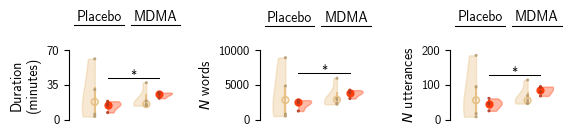

In [10]:
full_session_df = transcribe.combine_lines2sessions(full_line_df)
full_session_df["duration_mins"] = [dur/60.0 for dur in full_session_df["duration"]]
full_session_df["word_count"] = [len(text.split()) for text in full_session_df["text"]]
full_session_df["line_count"] = [len(full_line_df[full_line_df["session"] == session]) for session in full_session_df["session"]]
full_session_stat_dfs = utils.compute_group_differences(full_session_df, 
                                                        ["duration_mins", "word_count", "line_count"],
                                                        verbose=False)
utils.export_stats_tables(full_session_stat_dfs, table_path, "speech_full_sessions")

vars = ["duration_mins", "word_count", "line_count"]
var2yrange = {"duration_mins": [0, 70], 
             "word_count": [0, 10000],
             "line_count": [0, 200]}
var2label = {"duration_mins": "Duration\n(minutes)", 
             "word_count": r"$\it{N}$ words",
             "line_count": r"$\it{N}$ utterances"}
visualize.plot_speech_biotype_differences(full_session_df, full_session_stat_dfs, vars, var2yrange, var2label, 
                                          figure_path, "full_sessions", 
                                          biotypes=biotypes, conditions=conditions, 
                                          plot_points=True, plot_conditions=True, plot_biotypes=False)

##### Utterance level

###### Supplementary Figure 1d-e & Supplementary Table 2

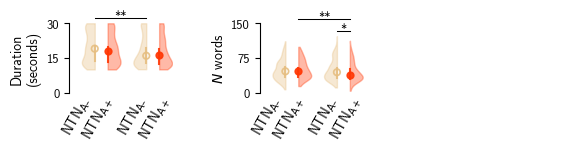

In [11]:
full_line_df["word_count"] = [len(text.split()) for text in full_line_df["text"]]
full_line_stat_dfs = utils.compute_group_differences(full_line_df, 
                                                     ["duration", "word_count"], 
                                                     verbose=False)
utils.export_stats_tables(full_line_stat_dfs, table_path, "speech_full_utterances")

vars = ["duration", "word_count"]
var2yrange = {"duration": [0, 30], 
             "word_count": [0, 150]}
var2label = {"duration": "Duration\n(seconds)", 
             "word_count": r"$\it{N}$ words"}
visualize.plot_speech_biotype_differences(full_line_df, full_line_stat_dfs, vars, var2yrange, var2label, 
                                          figure_path, "full_lines", 
                                          plot_points=False, plot_conditions=False, plot_biotypes=True)

#### Participant-only speech

##### Session level

###### Supplementary Figure 1f-h & Supplementary Table 3

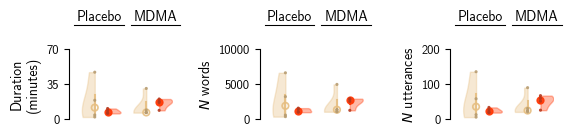

In [12]:
speech_session_df = transcribe.combine_lines2sessions(speech_line_df)
speech_session_df["duration_mins"] = [dur/60.0 for dur in speech_session_df["duration"]]
speech_session_df["word_count"] = [len(text.split()) for text in speech_session_df["text"]]
speech_session_df["line_count"] = [len(speech_line_df[speech_line_df["session"] == session]) for session in speech_session_df["session"]]

session_stat_dfs = utils.compute_group_differences(speech_session_df, 
                                                   ["duration_mins", "word_count", "line_count"],
                                                   verbose=False)
utils.export_stats_tables(session_stat_dfs, table_path, "speech_participant_sessions")

vars = ["duration_mins", "word_count", "line_count"]
var2yrange = {"duration_mins": [0, 70], 
             "word_count": [0, 10000],
             "line_count": [0, 200]}
var2label = {"duration_mins": "Duration\n(minutes)", 
             "word_count": r"$\it{N}$ words",
             "line_count": r"$\it{N}$ utterances"}

visualize.plot_speech_biotype_differences(speech_session_df, session_stat_dfs, vars, var2yrange, var2label, 
                                          figure_path, "sessions", 
                                          plot_points=True, plot_conditions=True, plot_biotypes=False)

##### Utterance level

###### Supplementary Figure 1i-j & Supplementary Table 4

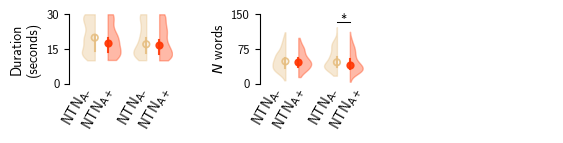

In [13]:
speech_line_df["word_count"] = [len(text.split()) for text in speech_line_df["text"]]

line_stat_dfs = utils.compute_group_differences(speech_line_df, 
                                                ["duration", "word_count"], 
                                                verbose=False)
utils.export_stats_tables(line_stat_dfs, table_path, "speech_participant_utterances")

vars = ["duration", "word_count"]
var2yrange = {"duration": [0, 30], 
             "word_count": [0, 150]}
var2label = {"duration": "Duration\n(seconds)", 
             "word_count": r"$\it{N}$ words"}

visualize.plot_speech_biotype_differences(speech_line_df, line_stat_dfs, vars, var2yrange, var2label, 
                                          figure_path, "lines", 
                                          plot_points=False, plot_conditions=False, plot_biotypes=True)

## 2. Candidate feature generation

### NLP features

In [14]:
nlp_vars = ["text_predicted_emotion",
            "n_first_person_singular_to_n_words", "n_first_person_plural_to_n_words", 
            "n_second_person_singular_to_n_words", "n_third_person_singular_to_n_words", "n_third_person_plural_to_n_words",
            "n_past_to_n_words", "n_present_to_n_words", "n_future_to_n_words", "n_hedges_to_n_words", "n_words",
            "audio_predicted_emotion",
            "words_per_sec", "pause_duration_per_sec", "jitter", "shimmer", "pitch_std"]

#### Affective valence features

In [15]:
valence_file = f"{feature_path}/valence_{max_dur}s.csv"

if not os.path.exists(valence_file):
    speech_line_df = featurize.load_roberta_features("roberta-base", model_path, 
                                                     speech_line_df, valence_file, max_dur=max_dur)
    speech_line_df = featurize.load_whisper_features("whisper-medium", model_path, 
                                                     speech_line_df, valence_file, max_dur=max_dur)
    
else:
    valence_df = pd.read_csv(valence_file)
    
    line2text_valence = {line: valence for line, valence in zip(valence_df["id"], valence_df["text_predicted_emotion"])}
    speech_line_df["text_predicted_emotion"] = [line2text_valence[line] for line in speech_line_df["id"]]

    line2audio_valence = {line: valence for line, valence in zip(valence_df["id"], valence_df["audio_predicted_emotion"])}
    speech_line_df["audio_predicted_emotion"] = [line2audio_valence[line] for line in speech_line_df["id"]]

#### Gramatical and acoustic features

In [16]:
speech_line_df = featurize.generate_nlp_features(speech_line_df)

### GPT features

#### Participant splits

###### Figure 1a

In [17]:
participant2split = featurize.split_participants(speech_line_df, seed=9, splits=["train", "valid", "test"])
for df in [speech_session_df, speech_block_df, speech_line_df]:
    df = featurize.load_participant_splits(df, participant2split, seed=seed, splits=splits)

In [18]:
print("-"*40 + "\nSESSION-LEVEL DATA (N PARTICIPANTS)\n" + "-"*40) 
print("\t\t\tLOW\tHIGH")   
for split in splits:
    print(split.upper())
    n_low = len(speech_session_df[(speech_session_df["split"] == split) & (speech_session_df["biotype"] == "low")])
    n_high = len(speech_session_df[(speech_session_df["split"] == split) & (speech_session_df["biotype"] == "high")])
    for condition in conditions:
        n_low_condition = len(speech_session_df[(speech_session_df["split"] == split) & (speech_session_df["biotype"] == "low") & (speech_session_df["condition"] == condition)])
        n_high_condition = len(speech_session_df[(speech_session_df["split"] == split) & (speech_session_df["biotype"] == "high") & (speech_session_df["condition"] == condition)])
        print(f"\t{condition.upper():10s}\t{n_low_condition}\t{n_high_condition}")
    print()
print()

print("-"*40 + "\nLINE-LEVEL DATA (N UTTERANCES)\n" + "-"*40) 
print("\t\t\tLOW\tHIGH")   
for split in splits:
    print(split.upper())
    n_low = len(speech_line_df[(speech_line_df["split"] == split) & (speech_line_df["biotype"] == "low")])
    n_high = len(speech_line_df[(speech_line_df["split"] == split) & (speech_line_df["biotype"] == "high")])
    for condition in conditions:
        n_low_condition = len(speech_line_df[(speech_line_df["split"] == split) & (speech_line_df["biotype"] == "low") & (speech_line_df["condition"] == condition)])
        n_high_condition = len(speech_line_df[(speech_line_df["split"] == split) & (speech_line_df["biotype"] == "high") & (speech_line_df["condition"] == condition)])
        print(f"\t{condition.upper():10s}\t{n_low_condition}\t{n_high_condition}")
    print()
print()

----------------------------------------
SESSION-LEVEL DATA (N PARTICIPANTS)
----------------------------------------
			LOW	HIGH
TRAIN
	PLACEBO   	2	2
	MDMA_HIGH 	3	2

VALID
	PLACEBO   	1	1
	MDMA_HIGH 	1	1

TEST
	PLACEBO   	1	1
	MDMA_HIGH 	1	1


----------------------------------------
LINE-LEVEL DATA (N UTTERANCES)
----------------------------------------
			LOW	HIGH
TRAIN
	PLACEBO   	139	51
	MDMA_HIGH 	130	74

VALID
	PLACEBO   	11	25
	MDMA_HIGH 	23	66

TEST
	PLACEBO   	57	17
	MDMA_HIGH 	29	58




#### Derive & quantify candidate GPT features

In [19]:
api_url = "https://aiapi-prod.stanford.edu/v1/chat/completions"
with open("../private/secureGPT.txt") as file:
    api_key = file.read()
    
gpt5_headers = {"Content-Type": "application/json",
                "Authorization": f"Bearer {api_key}"}

In [20]:
with open(f"{feature_path}/gpt5/gpt5_prompt_01_derive_features.txt") as file:
    prompt = file.read()

featurize.derive_gpt_features(speech_line_df, prompt, api_url, api_key, gpt5_headers, feature_path,
                              split="train",
                              min_n_vars=min_n_vars, max_n_vars=max_n_vars, max_n_iter=max_n_iter, 
                              biotypes=biotypes, conditions=conditions)

In [21]:
with open(f"{feature_path}/gpt5/gpt5_prompt_01_quantify_features.txt") as file:
    prompt = file.read()
    
featurize.quantify_gpt_features(speech_line_df, prompt, api_url, api_key, gpt5_headers, feature_path,
                                min_n_vars=min_n_vars, max_n_vars=max_n_vars, max_n_iter=max_n_iter, 
                                biotypes=biotypes, conditions=conditions)

In [22]:
gpt_dfs = featurize.load_gpt_features(speech_line_df, feature_path,
                                      min_n_vars=min_n_vars, max_n_vars=max_n_vars, max_n_iter=max_n_iter, 
                                      biotypes=biotypes, conditions=conditions)

## 3. Candidate feature filtering

Candidate features are eliminated if they do not trend higher (FDR<0.1) in one of the biotype subgroups when compared by Mann-Whitney U test in the training set.

In [23]:
sig_threshold = 0.1

### NLP features

In [24]:
nlp_stat_dfs = utils.compute_group_differences(speech_line_df[speech_line_df["split"] == "train"], nlp_vars, 
                                               verbose=False)

In [25]:
nlp_filt_dfs = featurize.filter_by_biotype_differences(speech_line_df, nlp_stat_dfs, nlp_vars, 
                                                       sig_threshold=sig_threshold, verbose=True)

PLACEBO    LOW   BIOTYPE   SELECTED VARS =  3 / 17
PLACEBO    HIGH  BIOTYPE   SELECTED VARS =  4 / 17
MDMA_HIGH  LOW   BIOTYPE   SELECTED VARS =  2 / 17
MDMA_HIGH  HIGH  BIOTYPE   SELECTED VARS =  3 / 17


In [26]:
print("Selected NLP Variables\n")
for condition in conditions:
    for biotype in biotypes:
        selected_vars = [var for var in nlp_filt_dfs[condition][biotype].columns if var in nlp_vars]
        print(f"{condition.upper():9s}  {biotype.upper():5s} BIOTYPE   SELECTED VARS = {", ".join(selected_vars)}")

Selected NLP Variables

PLACEBO    LOW   BIOTYPE   SELECTED VARS = n_first_person_singular_to_n_words, n_present_to_n_words, pitch_std
PLACEBO    HIGH  BIOTYPE   SELECTED VARS = audio_predicted_emotion, words_per_sec, pause_duration_per_sec, jitter
MDMA_HIGH  LOW   BIOTYPE   SELECTED VARS = n_first_person_singular_to_n_words, words_per_sec
MDMA_HIGH  HIGH  BIOTYPE   SELECTED VARS = n_second_person_singular_to_n_words, pause_duration_per_sec, jitter


### GPT features

In [27]:
gpt_stat_dfs = {}
for n_vars in range(min_n_vars, max_n_vars+1):
    gpt_stat_dfs[n_vars] = {}
    for n_iter in range(max_n_iter):
        gpt_stat_dfs[n_vars][n_iter] = {}
        for condition in conditions:
            gpt_stat_dfs[n_vars][n_iter][condition] = {}
            for biotype in biotypes:
                df = gpt_dfs[n_vars][n_iter][condition][biotype]
                vars = [var for var in df.columns if var.startswith("gpt5_") and var != "gpt5_ID"]
                gpt_stat_dfs[n_vars][n_iter][condition][biotype] = utils.compute_group_differences(df[df["split"] == "train"], vars, 
                                                                                                   verbose=False)

In [28]:
gpt_filt_dfs = {}
for n_vars in range(min_n_vars, max_n_vars+1):
    gpt_filt_dfs[n_vars] = {}
    for n_iter in range(max_n_iter):
        gpt_filt_dfs[n_vars][n_iter] = {}
        for condition in conditions:
            gpt_filt_dfs[n_vars][n_iter][condition] = {}
            for biotype in biotypes:
                
                df = gpt_dfs[n_vars][n_iter][condition][biotype]
                stat_dfs = gpt_stat_dfs[n_vars][n_iter][condition][biotype]
                vars = [var for var in df.columns if var.startswith("gpt5_") and var != "gpt5_ID"]
                filt_dfs = featurize.filter_by_biotype_differences(df, stat_dfs, vars, 
                                                                   sig_threshold=sig_threshold, verbose=False)
                gpt_filt_dfs[n_vars][n_iter][condition][biotype] = filt_dfs[condition][biotype]

In [29]:
print("Selected GPT Variables\n")
for n_vars in range(min_n_vars, max_n_vars+1):
    for n_iter in range(max_n_iter):
        print(f"VARIABLES = {n_vars}  ITERATION = {n_iter}")
        for condition in conditions:
            for biotype in biotypes:
                filt_df = gpt_filt_dfs[n_vars][n_iter][condition][biotype]
                selected_vars = [var for var in filt_df.columns if var.startswith("gpt5_")]
                print(f"{condition.upper():9s}  {biotype.upper():5s} BIOTYPE   SELECTED VARS = {", ".join(selected_vars)}")
        print()

Selected GPT Variables

VARIABLES = 1  ITERATION = 0
PLACEBO    LOW   BIOTYPE   SELECTED VARS = 
PLACEBO    HIGH  BIOTYPE   SELECTED VARS = 
MDMA_HIGH  LOW   BIOTYPE   SELECTED VARS = 
MDMA_HIGH  HIGH  BIOTYPE   SELECTED VARS = 

VARIABLES = 1  ITERATION = 1
PLACEBO    LOW   BIOTYPE   SELECTED VARS = 
PLACEBO    HIGH  BIOTYPE   SELECTED VARS = 
MDMA_HIGH  LOW   BIOTYPE   SELECTED VARS = 
MDMA_HIGH  HIGH  BIOTYPE   SELECTED VARS = 

VARIABLES = 1  ITERATION = 2
PLACEBO    LOW   BIOTYPE   SELECTED VARS = 
PLACEBO    HIGH  BIOTYPE   SELECTED VARS = 
MDMA_HIGH  LOW   BIOTYPE   SELECTED VARS = 
MDMA_HIGH  HIGH  BIOTYPE   SELECTED VARS = 

VARIABLES = 2  ITERATION = 0
PLACEBO    LOW   BIOTYPE   SELECTED VARS = 
PLACEBO    HIGH  BIOTYPE   SELECTED VARS = gpt5_context_vigilance_focus_drift
MDMA_HIGH  LOW   BIOTYPE   SELECTED VARS = 
MDMA_HIGH  HIGH  BIOTYPE   SELECTED VARS = 

VARIABLES = 2  ITERATION = 1
PLACEBO    LOW   BIOTYPE   SELECTED VARS = gpt5_emotional_bandwidth_management
PLACEBO   

## 4. Feature selection by logistic regression

In [30]:
param_grid = {"penalty": ["l2"],
              "C": [0.25, 0.5], 
              "max_iter": [1000],
              "tol": [0.0001],
              "fit_intercept": [True],
              "solver": ["lbfgs"],
              "random_state": [seed]}

### NLP features

###### Supplementary Table 7

In [31]:
nlp_clf_metrics, nlp_clfs = featurize.run_biotype_prediction(nlp_filt_dfs, speech_line_df, param_grid, 
                                                             biotypes=biotypes, conditions=conditions,
                                                             splits=splits, seed=seed, CI_width=CI_width, 
                                                             bootstrap_n_iter=bootstrap_n_iter, 
                                                             permutation_n_iter=permutation_n_iter)

---------------------------------------------------------------------------
MODELS TRAINED ON PLACEBO CONDITION
---------------------------------------------------------------------------
VARIABLES: n_first_person_singular_to_n_words, n_present_to_n_words, pitch_std, audio_predicted_emotion, words_per_sec, pause_duration_per_sec, jitter

Penalty: l2  C: 0.25  Max Iter: 1000  Intercept: True

TRAIN  N low = 190  N high = 190  Accuracy =  73.68%  CI = 68.42-78.95%  (p = 0.0016)
VALID  N low = 036  N high = 036  Accuracy =  44.44%  CI = 30.56-58.33%  (p = 0.0000)
TEST   N low = 074  N high = 074  Accuracy =  67.57%  CI = 58.11-77.03%  (p = 0.4818)

---------------------------------------------------------------------------
MODELS TRAINED ON MDMA_HIGH CONDITION
---------------------------------------------------------------------------
VARIABLES: n_first_person_singular_to_n_words, words_per_sec, n_second_person_singular_to_n_words, pause_duration_per_sec, jitter

Penalty: l2  C: 0.5  Max 

### GPT features

###### Supplementary Table 7

In [32]:
i = 0
gpt_valid_clf_metrics = {condition: pd.DataFrame() for condition in conditions}
for low_n_vars in range(min_n_vars, max_n_vars+1):
    for high_n_vars in range(min_n_vars, max_n_vars+1):
        for low_n_iter in range(max_n_iter):
            for high_n_iter in range(max_n_iter):
                
                gpt_combo_dfs = {}
                for condition in conditions:
                    gpt_combo_dfs[condition] = {"low": gpt_filt_dfs[low_n_vars][low_n_iter][condition]["low"],
                                                "high": gpt_filt_dfs[high_n_vars][high_n_iter][condition]["high"]}

                gpt_combo_clf_metrics, gpt_combo_clfs = featurize.run_biotype_prediction(gpt_combo_dfs, speech_line_df, param_grid, 
                                                                                         biotypes=biotypes, conditions=conditions,
                                                                                         splits=["train", "valid"], 
                                                                                         seed=seed, CI_width=CI_width, 
                                                                                         bootstrap_n_iter=1,
                                                                                         permutation_n_iter=1,
                                                                                         verbose=False)

                for condition in conditions:
                    if len(gpt_combo_clf_metrics[condition]) > 0:
                        gpt_combo_condition_clf_metrics = {"low_n_vars": low_n_vars, "high_n_vars": high_n_vars, "low_n_iter": low_n_iter, "high_n_iter": high_n_iter} 
                        gpt_combo_condition_clf_metrics = gpt_combo_condition_clf_metrics | gpt_combo_clf_metrics[condition]
                        gpt_combo_condition_clf_df = pd.DataFrame(gpt_combo_condition_clf_metrics, index=[i])
                        gpt_valid_clf_metrics[condition] = pd.concat([gpt_valid_clf_metrics[condition], gpt_combo_condition_clf_df])
                i += 1

In [33]:
gpt_top_params, gpt_top_dfs = {}, {}
for condition in conditions:
    top_params = gpt_valid_clf_metrics[condition].sort_values("accuracy_valid", ascending=False).head(1).squeeze().to_dict()
    gpt_top_params[condition] = top_params
    gpt_top_dfs[condition] = {"low": gpt_filt_dfs[top_params["low_n_vars"]][top_params["low_n_iter"]][condition]["low"],
                              "high": gpt_filt_dfs[top_params["high_n_vars"]][top_params["high_n_iter"]][condition]["high"]}

    print(f"{condition.upper():9s}  |  LOW N Vars = {top_params["low_n_vars"]:2d} ({top_params["low_n_vars_filtered"]} filtered)  LOW N Iter = {top_params["low_n_iter"]}  |  HIGH N Vars = {top_params["high_n_vars"]:2d} ({top_params["high_n_vars_filtered"]} filtered)  HIGH N Iter = {top_params["high_n_iter"]}")

PLACEBO    |  LOW N Vars =  7 (1 filtered)  LOW N Iter = 0  |  HIGH N Vars = 10 (4 filtered)  HIGH N Iter = 1
MDMA_HIGH  |  LOW N Vars =  3 (1 filtered)  LOW N Iter = 1  |  HIGH N Vars =  6 (3 filtered)  HIGH N Iter = 1


In [34]:
gpt_clf_metrics, gpt_clfs = featurize.run_biotype_prediction(gpt_top_dfs, speech_line_df, param_grid, 
                                                             biotypes=biotypes, conditions=conditions,
                                                             splits=splits, seed=seed, CI_width=CI_width, 
                                                             bootstrap_n_iter=bootstrap_n_iter, 
                                                             permutation_n_iter=bootstrap_n_iter)

---------------------------------------------------------------------------
MODELS TRAINED ON PLACEBO CONDITION
---------------------------------------------------------------------------
VARIABLES: gpt5_emotional_bandwidth_allocation, gpt5_professional_boundary_awareness, gpt5_performance_vigilance, gpt5_physiological_monitoring_hypotheses, gpt5_attention_state_oscillation

Penalty: l2  C: 0.5  Max Iter: 1000  Intercept: True

TRAIN  N low = 190  N high = 190  Accuracy =  85.79%  CI = 81.58-90.00%  (p = 0.0000)
VALID  N low = 036  N high = 036  Accuracy =  83.33%  CI = 72.22-91.67%  (p = 0.0000)
TEST   N low = 074  N high = 074  Accuracy =  74.32%  CI = 66.22-82.43%  (p = 0.0139)

---------------------------------------------------------------------------
MODELS TRAINED ON MDMA_HIGH CONDITION
---------------------------------------------------------------------------
VARIABLES: gpt5_boundary_conscious_social_restraint, gpt5_breath_self_regulation, gpt5_systems_policy_orientation, gpt5

In [35]:
for condition in conditions:
    for biotype in biotypes:
        speech_line_df = pd.merge(speech_line_df, gpt_top_dfs[condition][biotype], left_index=True, right_index=True, how="outer")

### NLP and GPT classifier comparison

###### Figure 1c

<b>Left panels:</b> Validation set performance. <b>Right panels:</b> Test set performance.

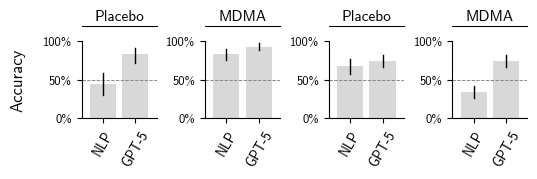

In [36]:
visualize.plot_classifier_comparison(nlp_clf_metrics, gpt_clf_metrics, figure_path)

### Speech data needed for logistic regression

###### Supplementary Figure 2

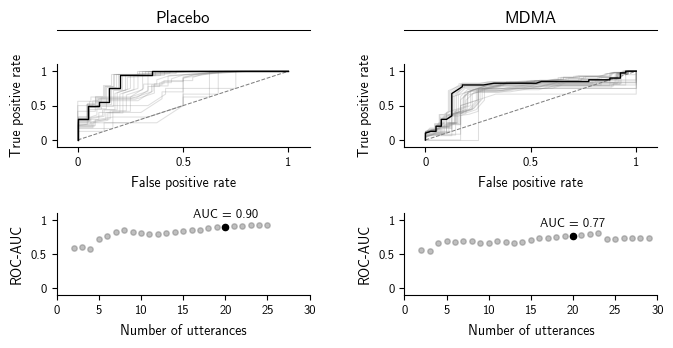


----------------------------------------------------------------------
PLACEBO
----------------------------------------------------------------------


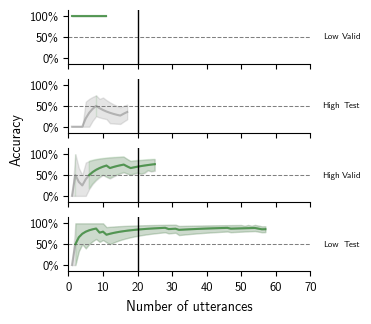


----------------------------------------------------------------------
MDMA_HIGH
----------------------------------------------------------------------


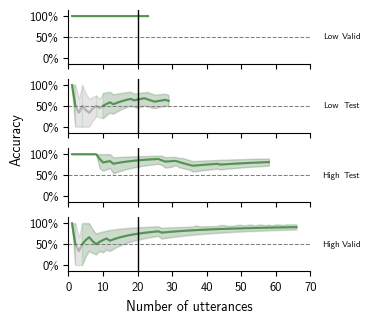

In [37]:
condition2line_thres = {"placebo": 20, "mdma_high": 20}
visualize.plot_roc_auc(gpt_clfs, speech_line_df, figure_path, condition2line_thres=condition2line_thres)
visualize.plot_accuracy_by_lines(gpt_clfs, speech_line_df, figure_path, condition2line_thres=condition2line_thres,
                                 bootstrap_n_iter=bootstrap_n_iter, CI_width=CI_width)

## 5. Statistical analysis

### NLP feature differences between biotype subgroups

###### Supplementary Figures 3-4 & Supplementary Tables 23-34

In [38]:
nlp_stat_dicts = {"sessions": {}, "blocks": {}}
for condition in conditions:
    nlp_condition_vars = list(nlp_filt_dfs[condition]["high"].columns) + list(nlp_filt_dfs[condition]["low"].columns)
    nlp_stat_dicts["sessions"][condition] = utils.compute_group_differences(speech_line_df, nlp_condition_vars, 
                                                                            verbose=False)
    nlp_stat_dicts["blocks"][condition] = utils.compute_group_block_differences(speech_line_df, nlp_condition_vars, 
                                                                                n_blocks=n_blocks, verbose=False)

utils.export_multilevel_stats_tables(nlp_stat_dicts, "nlp", table_path)

-------------------------------------------------------------------------------------
PLACEBO CONDITION
-------------------------------------------------------------------------------------
----------------------------------------------------------------------
FEATURES DIFFERENTIATING THE HIGH BIOTYPE IN THE PLACEBO CONDITION
----------------------------------------------------------------------


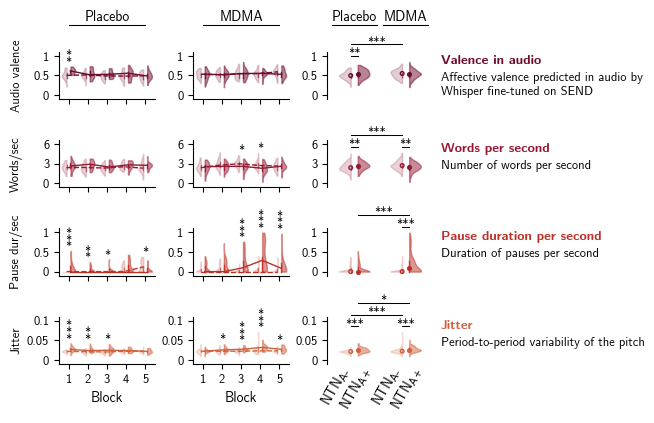

----------------------------------------------------------------------
FEATURES DIFFERENTIATING THE LOW BIOTYPE IN THE PLACEBO CONDITION
----------------------------------------------------------------------


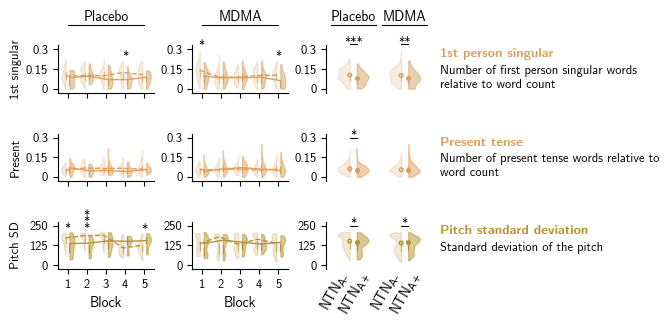

-------------------------------------------------------------------------------------
MDMA_HIGH CONDITION
-------------------------------------------------------------------------------------
----------------------------------------------------------------------
FEATURES DIFFERENTIATING THE HIGH BIOTYPE IN THE MDMA_HIGH CONDITION
----------------------------------------------------------------------


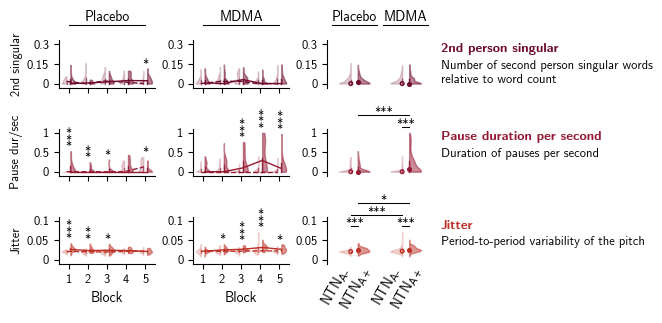

----------------------------------------------------------------------
FEATURES DIFFERENTIATING THE LOW BIOTYPE IN THE MDMA_HIGH CONDITION
----------------------------------------------------------------------


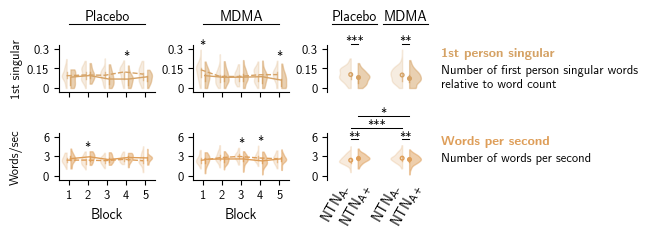

In [39]:
visualize.plot_feature_differences(nlp_filt_dfs, nlp_stat_dicts, speech_line_df, figure_path, "nlp",
                                   visualize.nlp2title, visualize.nlp2description, 
                                   visualize.nlp2label, visualize.nlp2yticks, 
                                   conditions=conditions, biotypes=biotypes, n_blocks=n_blocks)

### GPT feature differences between biotype subgroups

###### Figures 2-3 & Supplementary Tables 11-22

In [40]:
gpt_stat_dicts = {"sessions": {}, "blocks": {}}
gpt_vis_dfs = {}
for condition in conditions:
    gpt_condition_vars = []
    gpt_vis_dfs[condition] = {}
    for biotype in ["high", "low"]:
        gpt_condition_biotype_vars = list(gpt_top_dfs[condition][biotype].columns)
        sorted_df = gpt_top_dfs[condition][biotype][gpt_condition_biotype_vars].mean().sort_values(ascending=False)
        sorted_vars = list(sorted_df.index)
        gpt_condition_vars += sorted_vars
        gpt_vis_dfs[condition][biotype] = gpt_top_dfs[condition][biotype][sorted_vars]
        
    gpt_stat_dicts["sessions"][condition] = utils.compute_group_differences(speech_line_df, gpt_condition_vars, 
                                                                            verbose=False)
    gpt_stat_dicts["blocks"][condition] = utils.compute_group_block_differences(speech_line_df, gpt_condition_vars, 
                                                                                n_blocks=n_blocks, verbose=False)

utils.export_multilevel_stats_tables(gpt_stat_dicts, "gpt", table_path)

-------------------------------------------------------------------------------------
PLACEBO CONDITION
-------------------------------------------------------------------------------------
----------------------------------------------------------------------
FEATURES DIFFERENTIATING THE HIGH BIOTYPE IN THE PLACEBO CONDITION
----------------------------------------------------------------------


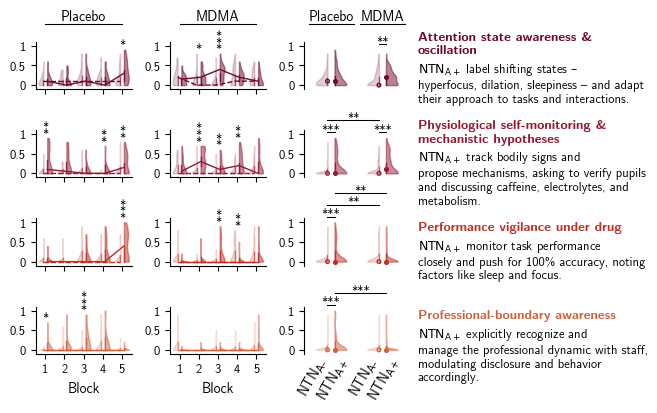

----------------------------------------------------------------------
FEATURES DIFFERENTIATING THE LOW BIOTYPE IN THE PLACEBO CONDITION
----------------------------------------------------------------------


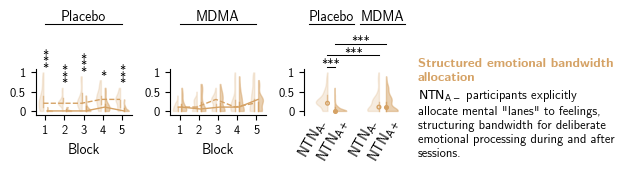

-------------------------------------------------------------------------------------
MDMA_HIGH CONDITION
-------------------------------------------------------------------------------------
----------------------------------------------------------------------
FEATURES DIFFERENTIATING THE HIGH BIOTYPE IN THE MDMA_HIGH CONDITION
----------------------------------------------------------------------


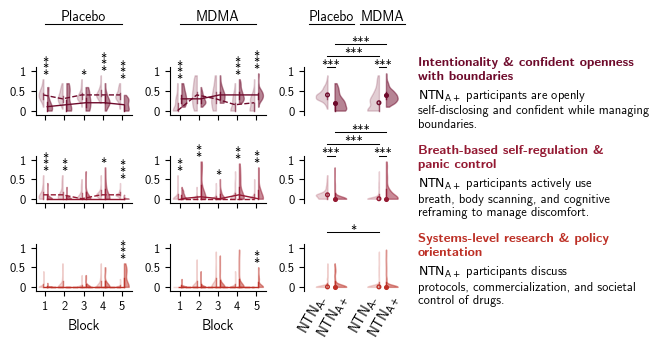

----------------------------------------------------------------------
FEATURES DIFFERENTIATING THE LOW BIOTYPE IN THE MDMA_HIGH CONDITION
----------------------------------------------------------------------


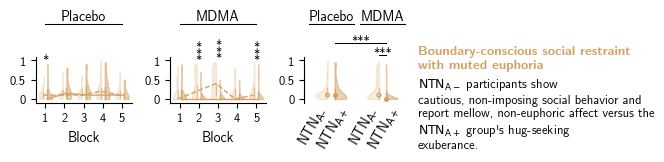

In [41]:
gpt2title, gpt2label, gpt2description, gpt2yticks = featurize.load_gpt_feature_info(gpt_top_params, feature_path, 
                                                                                    conditions=conditions, biotypes=biotypes)

visualize.plot_feature_differences(gpt_vis_dfs, gpt_stat_dicts, speech_line_df, figure_path, "gpt",
                                   gpt2title, gpt2description, gpt2label, gpt2yticks, 
                                   conditions=conditions, biotypes=biotypes, n_blocks=n_blocks)

### Grammatical person differences between biotype subgroups

###### Figure 4a & Supplementary Table 35

In [42]:
speech_line_df["n_third_person_to_n_words"] = ((speech_line_df["n_third_person_singular_to_n_words"] * speech_line_df["n_words"]) + (speech_line_df["n_third_person_plural_to_n_words"] * speech_line_df["n_words"])) / speech_line_df["n_words"]
person_vars = ["n_first_person_singular_to_n_words", "n_third_person_to_n_words"]

person_stat_dfs = utils.compute_group_differences(speech_line_df, person_vars, verbose=False)
utils.export_stats_tables(person_stat_dfs, table_path, "person_sessions")

### Grammatical person related to GPT "boundary openness"

###### Figure 4b & Supplementary Table 36

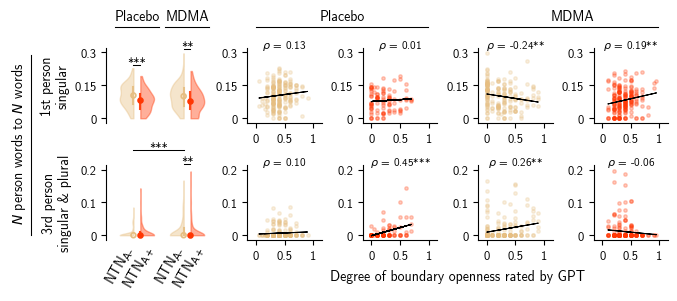

In [43]:
gpt_var = "gpt5_open_boundary_openness"

person_cor_dfs = utils.compute_session_correlation(speech_line_df, gpt_var, person_vars,
                                                   conditions=conditions, biotypes=biotypes,
                                                   stat=scipy.stats.spearmanr, CI_width=CI_width, 
                                                   bootstrap_n_iter=bootstrap_n_iter, verbose=False)

utils.export_correlation_tables(person_cor_dfs, person_vars, "person", table_path, 
                                level="sessions", stratification="biotype",
                                conditions=conditions, biotypes=biotypes)

visualize.plot_person_figure(speech_line_df, person_stat_dfs, person_cor_dfs, 
                             person_vars, gpt_var, figure_path, 
                             conditions=conditions, biotypes=biotypes)

### Affective valence differences between biotype subgroups

###### Figure 5a-b & Supplementary Tables 37-38

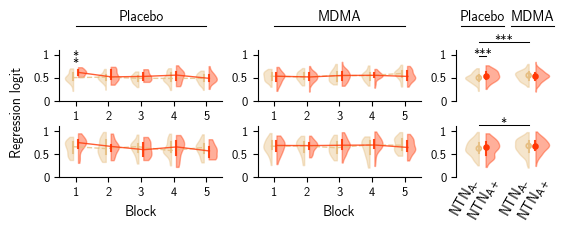

In [44]:
valence_vars = ["audio_predicted_emotion", "text_predicted_emotion"]

valence_stat_dicts = {}
valence_stat_dicts["sessions"] = utils.compute_group_differences(speech_line_df, valence_vars, 
                                                                 verbose=False)
utils.export_stats_tables(valence_stat_dicts["sessions"], table_path, "valence_sessions")

valence_stat_dicts["blocks"] = utils.compute_group_block_differences(speech_line_df, valence_vars, 
                                                                     n_blocks=n_blocks, verbose=False)
utils.export_stats_tables(valence_stat_dicts["blocks"], table_path, "valence_blocks")

visualize.plot_valence_differences(speech_line_df, valence_stat_dicts, valence_vars, figure_path)

### Affective valence related to GPT "boundary openness"

###### Figure 5c & Supplementary Table 39

---------------------------------------------------------------------------
AUDIO PREDICTED EMOTION
---------------------------------------------------------------------------


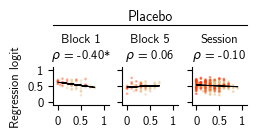

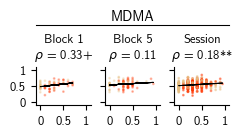

In [45]:
valence_cor_dfs = {}
valence_cor_dfs["sessions"] = utils.compute_session_correlation(speech_line_df, gpt_var, valence_vars,
                                                                stratification=None, 
                                                                conditions=conditions, biotypes=biotypes, 
                                                                stat=scipy.stats.spearmanr, CI_width=CI_width, 
                                                                bootstrap_n_iter=bootstrap_n_iter, verbose=False)

utils.export_correlation_tables(valence_cor_dfs["sessions"], valence_vars, "valence", table_path, 
                                level="sessions", stratification=None, 
                                conditions=conditions, biotypes=biotypes)

valence_cor_dfs["blocks"] = utils.compute_block_correlation(speech_line_df, gpt_var, valence_vars,
                                                            stratification=None, 
                                                            conditions=conditions, biotypes=biotypes, 
                                                            stat=scipy.stats.spearmanr, CI_width=CI_width, 
                                                            bootstrap_n_iter=bootstrap_n_iter, verbose=False)

utils.export_correlation_tables(valence_cor_dfs["blocks"], valence_vars, "valence", table_path, 
                                level="blocks", stratification=None, 
                                conditions=conditions, biotypes=biotypes)

visualize.plot_valence_correlations(speech_line_df, valence_cor_dfs, "audio_predicted_emotion", gpt_var, figure_path)

### VAS "loving" differences between biotype subgroups

###### Figure 5d-e & Supplementary Tables 40-41

In [46]:
vas_block_df = utils.load_vas_df(f"{data_path}/vas_labeled.csv")
vas_vars = [var for var in vas_block_df.columns if var.startswith("vas_")]

if not set(vas_vars).issubset(speech_block_df.columns):
    speech_block_df.index = [f"{session}_{block}" for session, block in zip(speech_block_df["session"], speech_block_df["block"])]
    speech_block_df = pd.merge(speech_block_df, vas_block_df[vas_vars], left_index=True, right_index=True, how="inner")

gpt_vars = [var for var in speech_line_df if var.startswith("gpt5_")]
if not set(gpt_vars).issubset(speech_session_df.columns):
    gpt_session_df = speech_line_df[["session"] + gpt_vars].groupby("session").mean()
    speech_session_df = pd.merge(speech_session_df, gpt_session_df[gpt_vars], left_index=True, right_index=True, how="inner")

if not set(vas_vars).issubset(speech_session_df.columns):
    vas_session_df = speech_block_df[["session"] + vas_vars].groupby("session").mean()
    speech_session_df = pd.merge(speech_session_df, vas_session_df[vas_vars], left_index=True, right_index=True, how="inner")

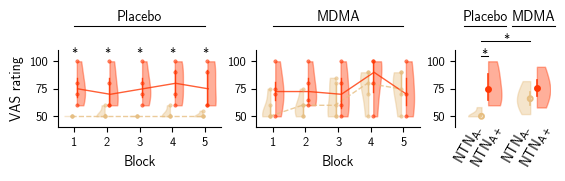

In [47]:
loving_vars = ["vas_loving"]

loving_stat_dicts = {}
loving_stat_dicts["sessions"] = utils.compute_group_differences(speech_session_df, loving_vars, 
                                                                verbose=False)
utils.export_stats_tables(loving_stat_dicts["sessions"], table_path, "loving_sessions")

loving_stat_dicts["blocks"] = utils.compute_group_block_differences(speech_block_df, loving_vars, 
                                                                    n_blocks=n_blocks, verbose=False)
utils.export_stats_tables(loving_stat_dicts["blocks"], table_path, "loving_blocks")

visualize.plot_vas_differences(speech_block_df, speech_session_df, loving_stat_dicts, loving_vars, figure_path)

### VAS "defensive," "loving," & "calm" related to GPT "boundary openness"

###### Figure 5f & Supplementary Table 42

---------------------------------------------------------------------------
VAS DEFENSIVENESS
---------------------------------------------------------------------------


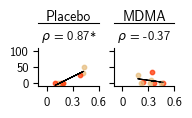


---------------------------------------------------------------------------
VAS LOVING
---------------------------------------------------------------------------


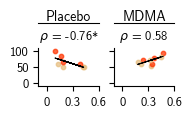


---------------------------------------------------------------------------
VAS CALM
---------------------------------------------------------------------------


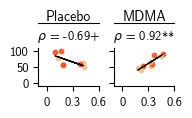

In [48]:
vas_selected_vars = ["vas_defensiveness", "vas_loving", "vas_calm"]

vas_cor_df = utils.compute_session_correlation(speech_session_df, gpt_var, vas_selected_vars,
                                               stratification=None,
                                               conditions=conditions, biotypes=biotypes,
                                               stat=scipy.stats.spearmanr, CI_width=CI_width, 
                                               bootstrap_n_iter=1000, verbose=False, seed=seed)

utils.export_correlation_tables(vas_cor_df, vas_selected_vars, "vas", table_path,
                                level="sessions", stratification=None, 
                                conditions=conditions, biotypes=biotypes)

visualize.plot_vas_correlations(speech_session_df, vas_cor_df, vas_selected_vars, gpt_var, figure_path)